# Task 4 — Step 1: Vanilla Closed-Set Baseline

A 10-way CIFAR-10 classifier trained with cross-entropy. It is the fixed model on which all post-hoc novelty scores are compared (notebook 2), and the initialisation for PROSER (notebook 4).

| Item | Setting (manual) |
|---|---|
| Architecture | ResNet-18, CIFAR stem: 3×3 stride-1 first conv, **no max-pool**, 32×32 inputs, random init |
| Augmentation | RandomCrop(32, padding 4) + horizontal flip |
| Optimiser | SGD lr 0.1, momentum 0.9, wd 5e-4, cosine decay (per step) |
| Budget | batch 128, **100 epochs** (`CLOSED_SET_EPOCHS`, as in the manual; per-step cosine decay), seed 6304 |
| Selection | highest CIFAR-10 **validation** accuracy (stratified 90/10 split of the official train set, seed 6304) |

**Ordering rule.** Unknown (CIFAR-100) images are *not* touched here. They are first loaded in notebook 2, after Vanilla, GCSC and PROSER are all trained and every score and threshold rule is fixed. This notebook caches the known-class features/logits used by every score. bf16 autocast is used for training speed only; cached outputs are computed in fp32.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if not os.path.isdir(os.path.join(ROOT, 'task4_open_set')) and os.path.isdir('/content/task4_open_set'):
    ROOT = '/content'                    # running on a Colab server (see 0_colab_setup.ipynb)
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torchvision import datasets

from shared.src.seed import set_seed, SEED
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, NEUTRAL, INK_2, color_of, save_show, bar_labels
from shared.src.diagrams import cifar_resnet_diagram
from sklearn.manifold import TSNE
from task4_open_set.src.data import (get_cifar10, make_loader, make_or_load_split, CIFAR10_CLASSES, CIFAR10_ROOT,
                                     TRAIN_TF, MEAN, STD, denorm)
from task4_open_set.src.resnet_cifar import ResNetCIFAR
from task4_open_set.src.train import train_closed_set, extract_outputs, val_accuracy, CLOSED_SET_EPOCHS

use_style()
set_seed(SEED)
device = torch.device('cuda')
T4 = os.path.join(ROOT, 'task4_open_set')
CKPT, CACHE, RES = [os.path.join(T4, d) for d in ('checkpoints', 'cache', 'results')]
for d in (CKPT, CACHE, RES): os.makedirs(d, exist_ok=True)
print('device', device, '| seed', SEED)

device cuda | seed 6304


## 0. Download CIFAR-10
Downloads the official archive (~163 MB) from www.cs.toronto.edu into `data/cifar10/` (gitignored). It is skipped if the verified archive is already there. If you already have `cifar-10-python.tar.gz`, place it in `data/cifar10/` first and the cell will only extract it.

In [2]:
from task4_open_set.src.data import CIFAR100_ROOT
datasets.CIFAR10(CIFAR10_ROOT, train=True, download=True)
datasets.CIFAR10(CIFAR10_ROOT, train=False, download=True)
print('CIFAR-10 ready in', CIFAR10_ROOT)

CIFAR-10 ready in /kaggle/working/pa1/data/cifar10


## 1. Known-class data and the 90/10 split

train 45000 | val 5000 | test 10000 | split file: task4_open_set/splits/cifar10_seed6304.json


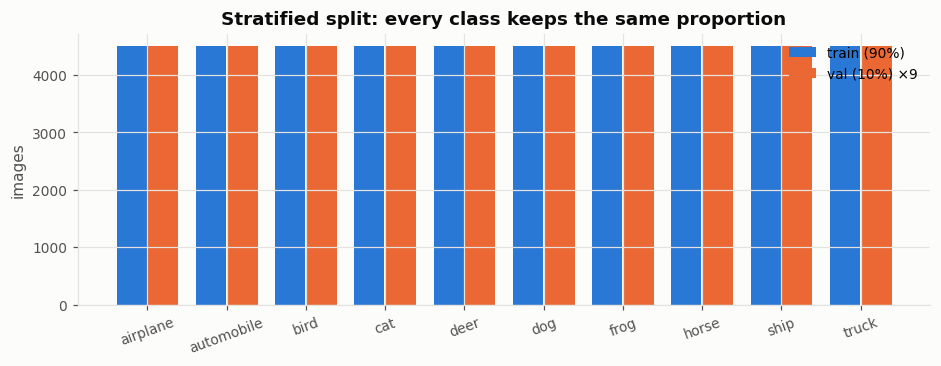

In [3]:
split = make_or_load_split()
train_aug, train_plain, val_ds, test_ds = get_cifar10(TRAIN_TF)
tr_labels = np.array(datasets.CIFAR10(CIFAR10_ROOT, train=True).targets)
print(f"train {len(train_aug)} | val {len(val_ds)} | test {len(test_ds)} | split file: task4_open_set/splits/cifar10_seed6304.json")
fig, ax = plt.subplots(figsize=(10, 3.2))
w = 0.4
ax.bar(np.arange(10) - w / 2, np.bincount(tr_labels[split['train_idx']], minlength=10), w * 0.95, color=PALETTE[0], label='train (90%)')
ax.bar(np.arange(10) + w / 2, np.bincount(tr_labels[split['val_idx']], minlength=10) * 9, w * 0.95, color=PALETTE[1], label='val (10%) ×9')
ax.set_xticks(range(10)); ax.set_xticklabels(CIFAR10_CLASSES, rotation=20); ax.set_ylabel('images'); ax.legend()
ax.set_title('Stratified split: every class keeps the same proportion')
save_show(fig, os.path.join(RES, 'cifar10_split_balance.png'))

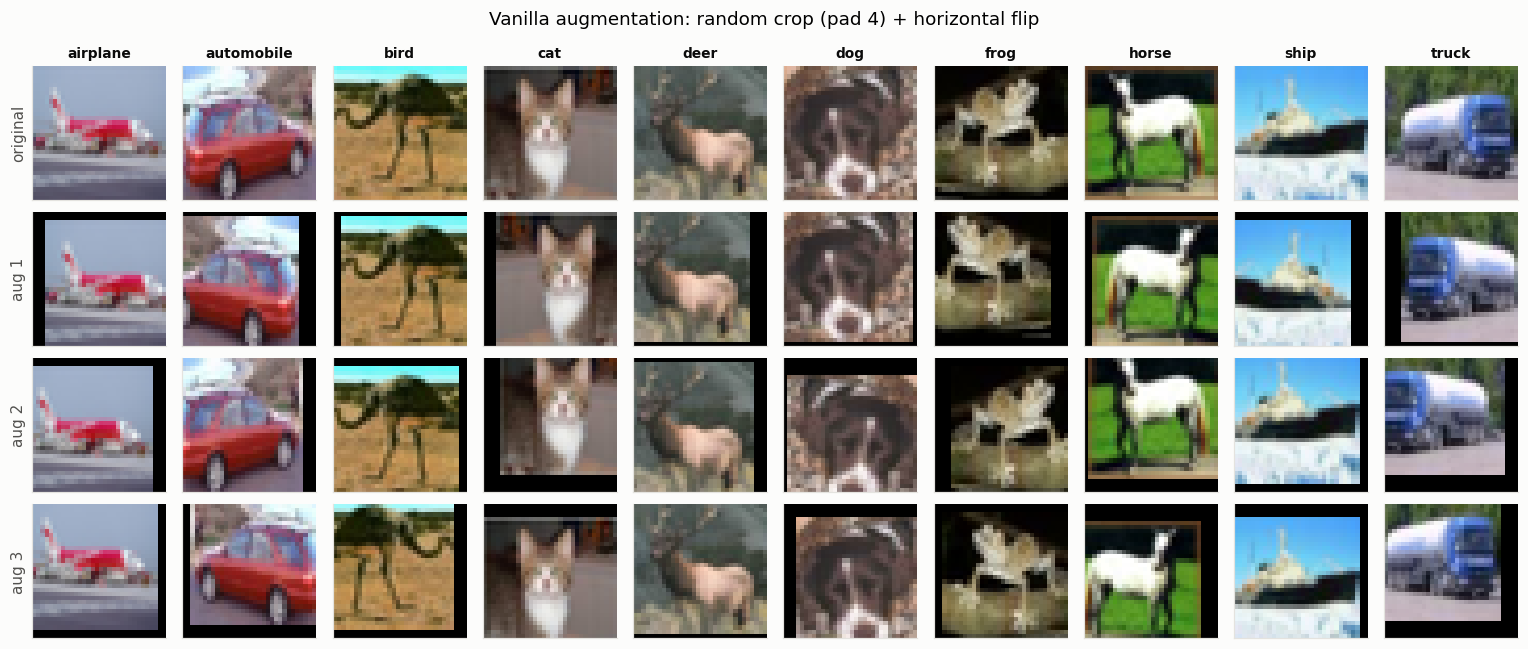

In [4]:
# One raw image per class and three augmented views of it (what the network actually sees)
raw = datasets.CIFAR10(CIFAR10_ROOT, train=True)
rng = np.random.RandomState(SEED)
mean, std = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
for c in range(10):
    i = int(rng.choice(np.where(tr_labels == c)[0]))
    img = raw[i][0]
    axes[0, c].imshow(img); axes[0, c].set_title(CIFAR10_CLASSES[c], fontsize=9)
    for r in range(1, 4):
        axes[r, c].imshow((TRAIN_TF(img) * std + mean).clamp(0, 1).permute(1, 2, 0))
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([]); a.grid(False)
axes[0, 0].set_ylabel('original'); [axes[r, 0].set_ylabel(f'aug {r}') for r in range(1, 4)]
fig.suptitle('Vanilla augmentation: random crop (pad 4) + horizontal flip', fontsize=12); fig.tight_layout()
save_show(fig, os.path.join(RES, 'vanilla_augmentation_samples.png'))

## 2. CIFAR ResNet-18

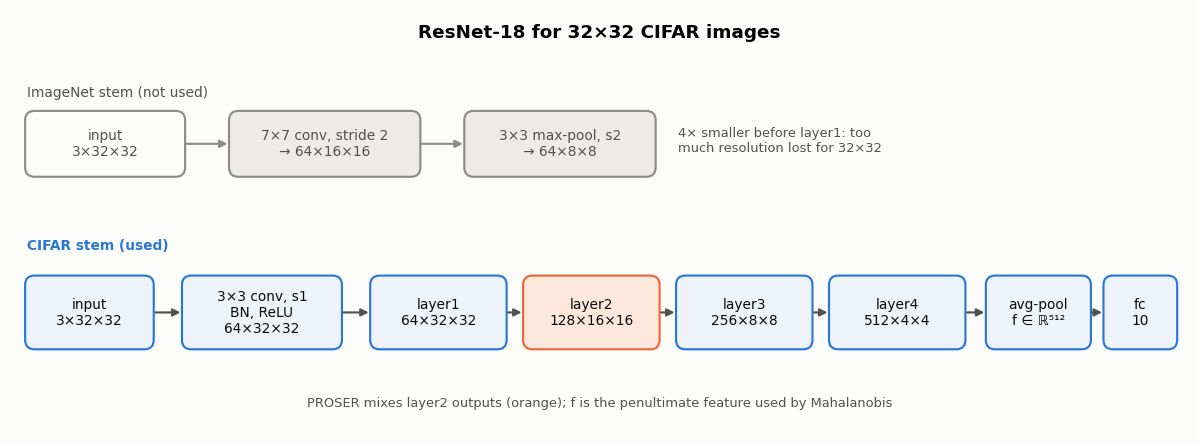

In [5]:
fig = cifar_resnet_diagram()
save_show(fig, os.path.join(RES, 'cifar_resnet18_diagram.png'))

In [6]:
set_seed(SEED)
model = ResNetCIFAR(num_classes=10)
print('first conv:', model.conv1)
print('max-pool present:', any(isinstance(m, torch.nn.MaxPool2d) for m in model.modules()))
with torch.no_grad():
    lg, f = model(torch.zeros(2, 3, 32, 32))
print('logits', tuple(lg.shape), '| penultimate feature', tuple(f.shape), f'| params {sum(p.numel() for p in model.parameters()):,}')

first conv: Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
max-pool present: False
logits (2, 10) | penultimate feature (2, 512) | params 11,173,962


In [7]:
# Feature-map shape after every stage (forward hooks on a dummy batch), confirming the 32x32 CIFAR stem
shapes = []
hooks = [getattr(model, n).register_forward_hook(lambda m, i, o, n=n: shapes.append((n, tuple(o.shape[1:]))))
         for n in ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool', 'fc']]
with torch.no_grad():
    model(torch.zeros(1, 3, 32, 32))
for h in hooks: h.remove()
pd.DataFrame(shapes, columns=['module', 'output shape (C, H, W)']).set_index('module')

,"output shape (C, H, W)"
module,
conv1,"(64, 32, 32)"
layer1,"(64, 32, 32)"
layer2,"(128, 16, 16)"
layer3,"(256, 8, 8)"
layer4,"(512, 4, 4)"
avgpool,"(512, 1, 1)"
fc,"(10,)"


## 3. Train

In [8]:
FORCE_TRAIN = True
ckpt_path, hist_path = os.path.join(CKPT, 'vanilla.pth'), os.path.join(CKPT, 'vanilla_history.json')
CONFIG = dict(epochs=CLOSED_SET_EPOCHS, lr=0.1, momentum=0.9, weight_decay=5e-4, batch_size=128, schedule='cosine (per step)', augmentation='crop+flip', seed=SEED)
if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    model = ResNetCIFAR(num_classes=10)
    train_loader = make_loader(train_aug, train=True, batch_size=128)
    val_loader = make_loader(val_ds, train=False, batch_size=512)
    out = train_closed_set(model, train_loader, val_loader, device, epochs=CLOSED_SET_EPOCHS, lr=0.1, save_path=ckpt_path, log_every=1)
    hist, best_epoch = out['history'], out['best_epoch']
    json.dump({'config': CONFIG, 'history': hist, 'best_epoch': best_epoch, 'best_val_acc': out['best_val_acc']}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); hist, best_epoch = meta['history'], meta['best_epoch']
model = ResNetCIFAR(num_classes=10).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f'selected epoch {best_epoch} | val acc {max(hist["val_acc"]):.4f}')

mixed precision: torch.float16
ep   1 | loss 2.035 | train acc 0.2723 | val acc 0.3674 * | 15s
ep   2 | loss 1.453 | train acc 0.4610 | val acc 0.4916 * | 13s
ep   3 | loss 1.199 | train acc 0.5641 | val acc 0.6206 * | 13s
ep   4 | loss 1.013 | train acc 0.6388 | val acc 0.6284 * | 13s
ep   5 | loss 0.857 | train acc 0.6981 | val acc 0.6976 * | 14s
ep   6 | loss 0.723 | train acc 0.7468 | val acc 0.7152 * | 14s
ep   7 | loss 0.637 | train acc 0.7783 | val acc 0.6918 | 14s
ep   8 | loss 0.584 | train acc 0.7981 | val acc 0.7552 * | 14s
ep   9 | loss 0.545 | train acc 0.8122 | val acc 0.7970 * | 15s
ep  10 | loss 0.523 | train acc 0.8192 | val acc 0.7514 | 15s
ep  11 | loss 0.493 | train acc 0.8293 | val acc 0.7798 | 15s
ep  12 | loss 0.477 | train acc 0.8364 | val acc 0.7900 | 14s
ep  13 | loss 0.461 | train acc 0.8411 | val acc 0.7030 | 14s
ep  14 | loss 0.452 | train acc 0.8450 | val acc 0.7872 | 14s
ep  15 | loss 0.427 | train acc 0.8536 | val acc 0.8130 * | 15s
ep  16 | loss 0.415 |

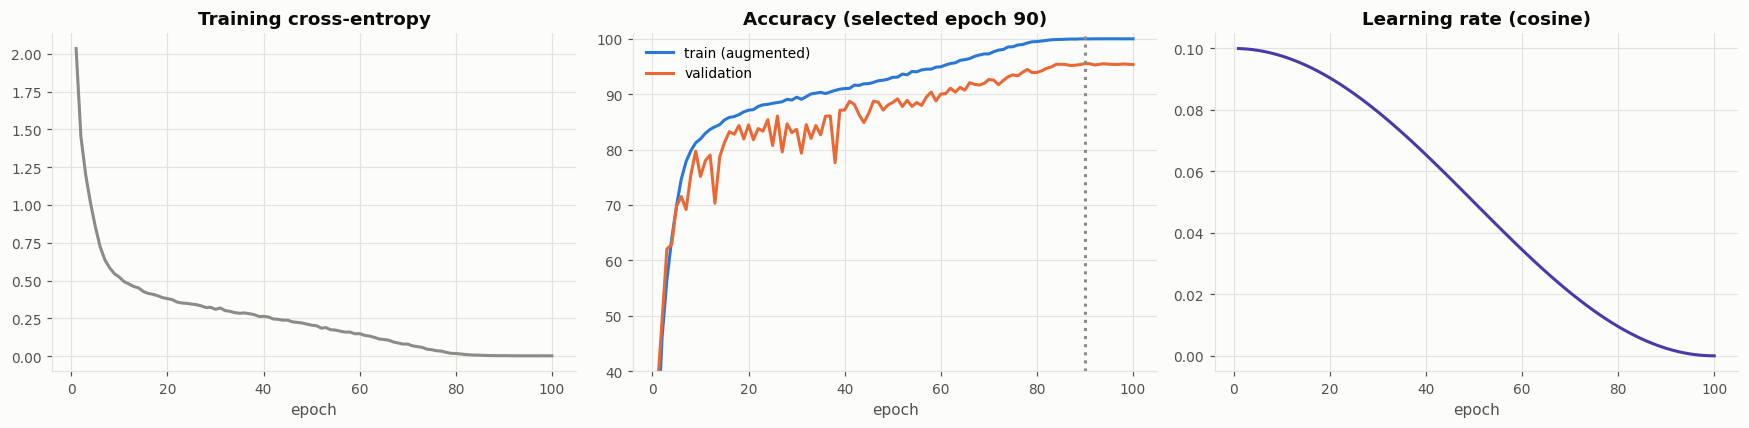

In [9]:
ep = np.arange(1, len(hist['train_loss']) + 1)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 4))
a1.plot(ep, hist['train_loss'], color=color_of('Vanilla')); a1.set_title('Training cross-entropy'); a1.set_xlabel('epoch')
a2.plot(ep, 100 * np.array(hist['train_acc']), color=PALETTE[0], label='train (augmented)')
a2.plot(ep, 100 * np.array(hist['val_acc']), color=PALETTE[1], label='validation')
a2.axvline(best_epoch, color=NEUTRAL, ls=':'); a2.set_ylim(40, 101); a2.set_title(f'Accuracy (selected epoch {best_epoch})'); a2.legend(); a2.set_xlabel('epoch')
a3.plot(ep, hist['lr'], color=PALETTE[6]); a3.set_title('Learning rate (cosine)'); a3.set_xlabel('epoch')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'vanilla_training_curves.png'))

## 4. Closed-set accuracy on the CIFAR-10 test set

In [10]:
loaders = {'train': make_loader(train_plain, False, 512), 'val': make_loader(val_ds, False, 512), 'test': make_loader(test_ds, False, 512)}
outs = {k: extract_outputs(model, l, device) for k, l in loaders.items()}
np.savez_compressed(os.path.join(CACHE, 'vanilla_known.npz'), **{f'{k}_{f}': v for k, o in outs.items() for f, v in o.items()})
pred = outs['test']['logits'].argmax(1); y = outs['test']['labels']
csa = (pred == y).mean()
print(f"CIFAR-10 test accuracy (CSA): {100*csa:.2f}% | val {100*(outs['val']['logits'].argmax(1)==outs['val']['labels']).mean():.2f}%")
print('cached -> task4_open_set/cache/vanilla_known.npz (train [unaugmented] / val / test features + logits)')
json.dump({'csa': float(csa)}, open(os.path.join(RES, 'vanilla_csa.json'), 'w'))

CIFAR-10 test accuracy (CSA): 94.81% | val 95.52%
cached -> task4_open_set/cache/vanilla_known.npz (train [unaugmented] / val / test features + logits)


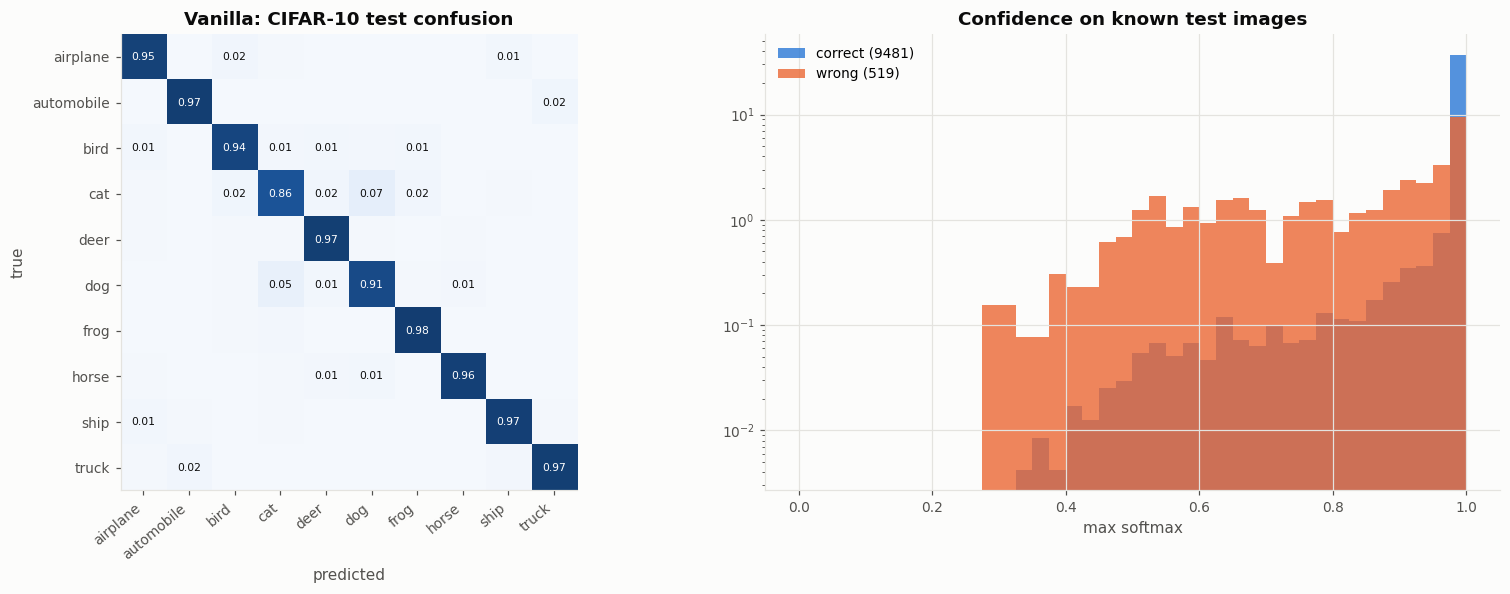

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
per-class test acc (%),95.4,97.4,93.5,86.2,97.0,90.9,97.7,96.2,96.8,97.0


In [11]:
cm = confusion_matrix(y, pred); cm_n = cm / cm.sum(1, keepdims=True)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.2, 1]})
im = a1.imshow(cm_n, cmap=SEQ_CMAP, vmin=0, vmax=1)
for i in range(10):
    for j in range(10):
        if cm_n[i, j] >= 0.01: a1.text(j, i, f"{cm_n[i, j]:.2f}", ha='center', va='center', fontsize=7, color='white' if cm_n[i, j] > 0.55 else '#0b0b0b')
a1.set_xticks(range(10)); a1.set_xticklabels(CIFAR10_CLASSES, rotation=40, ha='right'); a1.set_yticks(range(10)); a1.set_yticklabels(CIFAR10_CLASSES)
a1.set_title('Vanilla: CIFAR-10 test confusion'); a1.grid(False); a1.set_xlabel('predicted'); a1.set_ylabel('true')
conf = torch.softmax(torch.tensor(outs['test']['logits']), 1).max(1).values.numpy()
bins = np.linspace(0, 1, 41)
a2.hist(conf[pred == y], bins=bins, color=PALETTE[0], alpha=0.8, label=f'correct ({(pred==y).sum()})', density=True)
a2.hist(conf[pred != y], bins=bins, color=PALETTE[1], alpha=0.8, label=f'wrong ({(pred!=y).sum()})', density=True)
a2.set_yscale('log'); a2.set_xlabel('max softmax'); a2.set_title('Confidence on known test images'); a2.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'vanilla_test_analysis.png'))
pd.Series(100 * np.diag(cm_n), index=CIFAR10_CLASSES, name='per-class test acc (%)').round(2).to_frame().T

## 5. Per-class accuracy, feature space and confident mistakes

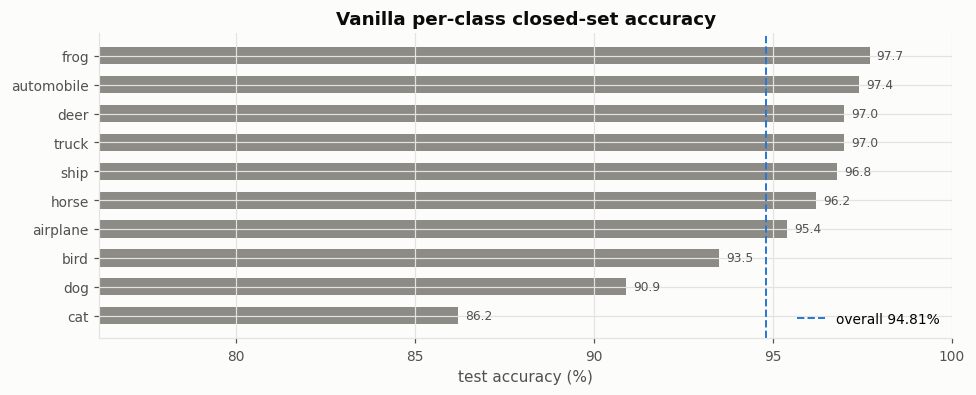

In [12]:
pc = 100 * np.diag(cm_n); order = np.argsort(pc)
fig, a = plt.subplots(figsize=(10, 3.6))
b = a.barh(np.array(CIFAR10_CLASSES)[order], pc[order], color=color_of('Vanilla'), height=0.6)
for bb in b: a.text(bb.get_width() + 0.2, bb.get_y() + bb.get_height() / 2, f'{bb.get_width():.1f}', va='center', fontsize=8, color=INK_2)
a.axvline(100 * csa, color=PALETTE[0], ls='--', lw=1.3, label=f'overall {100*csa:.2f}%'); a.set_xlim(max(0, pc.min() - 10), 100)
a.set_xlabel('test accuracy (%)'); a.set_title('Vanilla per-class closed-set accuracy'); a.legend(loc='lower right')
save_show(fig, os.path.join(RES, 'vanilla_per_class_accuracy.png'))

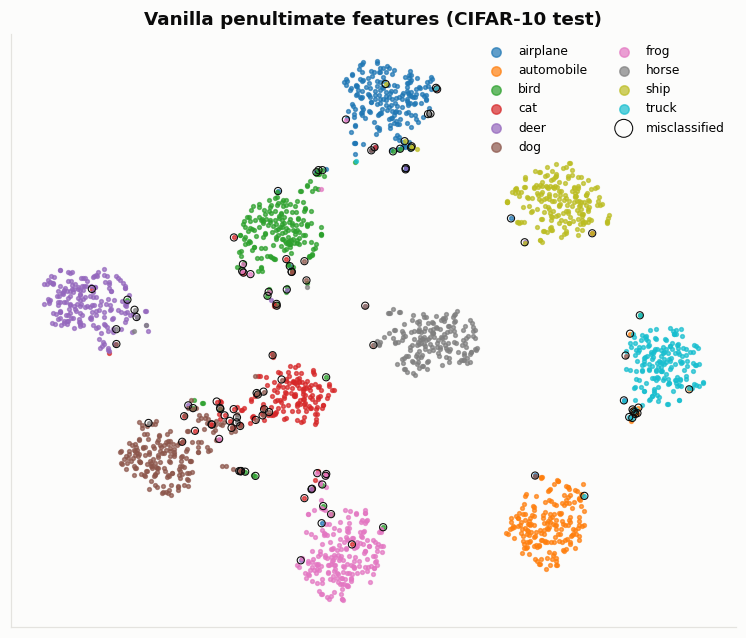

In [13]:
# t-SNE of penultimate test features (2,000 images, seed 6304): how compact are the known classes?
sel = np.random.RandomState(SEED).choice(len(y), 2000, replace=False)
E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(outs['test']['feats'][sel])
cmap10 = plt.get_cmap('tab10')
fig, a = plt.subplots(figsize=(8.5, 7))
for c in range(10):
    s = y[sel] == c; a.scatter(E[s, 0], E[s, 1], s=6, alpha=0.7, color=cmap10(c), label=CIFAR10_CLASSES[c])
wrong = pred[sel] != y[sel]
a.scatter(E[wrong, 0], E[wrong, 1], s=22, facecolors='none', edgecolors='#0b0b0b', linewidths=0.7, label='misclassified')
a.set_xticks([]); a.set_yticks([]); a.set_title('Vanilla penultimate features (CIFAR-10 test)'); a.legend(markerscale=2.5, fontsize=8, ncol=2)
save_show(fig, os.path.join(RES, 'vanilla_test_tsne.png'))

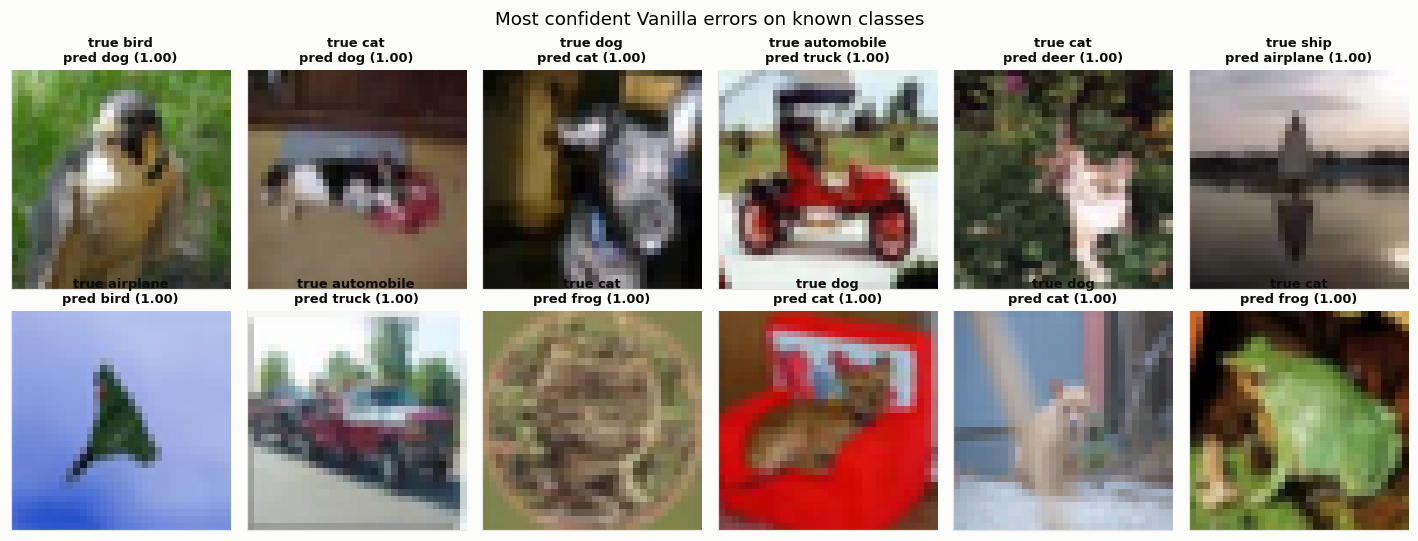

In [14]:
# The 12 most confident mistakes on the known test set
probs = torch.softmax(torch.tensor(outs['test']['logits']), 1).numpy(); conf = probs.max(1)
worst = np.argsort(-(conf * (pred != y)))[:12]
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for ax, i in zip(axes.ravel(), worst):
    ax.imshow(denorm(test_ds[int(i)][0])); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f'true {CIFAR10_CLASSES[y[i]]}\npred {CIFAR10_CLASSES[pred[i]]} ({conf[i]:.2f})', fontsize=8.5)
fig.suptitle('Most confident Vanilla errors on known classes', fontsize=12); fig.tight_layout()
save_show(fig, os.path.join(RES, 'vanilla_confident_errors.png'))